# Multi-Agent System for Transit Anomaly Detection
## Companion notebook to `Classical_approach.ipynb`

This notebook re-implements the same anomaly-detection logic as the classical
pipeline, but as a **specialist-agent system** orchestrated with LangGraph.
The classical pipeline is the analytical reference; the multi-agent pipeline
is the interactive layer on top, exposing the same evidence through a natural-
language perimeter selector and a structured report.

The numbering continues from the classical notebook (sections 1–14 there) so
that the two files compose a single deliverable.

The cleaning, route aggregation, segmented rates, log1p+StandardScaler
transformation and the 4-detector ensemble are all reused as deterministic
helper functions. The LLM is used only at two points: (i) to parse the
free-text user request into a structured perimeter, (ii) to write a short
narrative interpretation on top of the deterministic numbers. Every metric,
threshold, vote and ranking is computed in Python; the LLM never invents
report facts.

## 15. Setup

### 15.1 Imports and configuration

We load the scientific stack (numpy, pandas, scikit-learn), LangGraph for the
orchestrator, LangChain’s `ChatOllama` wrapper for the local LLM, and the
project-wide constants (`RANDOM_STATE`, `CONTAMINATION`) from the classical
notebook. Both raw datasets are read here — the multi-agent notebook is
self-contained and does not depend on intermediate files written by the
classical pipeline.

In [37]:
import io, json, re, time, warnings
from pathlib import Path
from typing import TypedDict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage
from langchain_ollama import ChatOllama

from IPython.display import display, Markdown

# === ALL business logic comes from utils.py (shared with classical) ===
from utils import (
    RANDOM_STATE, CONTAMINATION, DISQUALIFYING_FLAGS,
    IATA_MAPPING, CITY_TO_IATA, IT_TO_ALPHA3,
    load_clean_data, build_route_master, build_feature_matrix,
    fit_detectors, wilson_ci, quality_note, apply_post_processing,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams["figure.dpi"] = 120
NAVY, STEEL, CORAL, GREEN = "#1A3764", "#4682B4", "#E8735A", "#27AE60"

MIN_ROUTES_FOR_DETECTION = 10
LLM_MODEL                = "llama3.2:3b"

# === fix #6: deterministic LLM kwargs ===
LLM_KWARGS = {"model": LLM_MODEL, "temperature": 0, "seed": RANDOM_STATE}

IO_DIR     = Path.cwd() / "io"
REPORT_DIR = IO_DIR / "agent_report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

t_start = time.time()
print(f"Stack loaded — random_state={RANDOM_STATE}, contamination={CONTAMINATION}, "
      f"LLM seed={LLM_KWARGS['seed']}")

Stack loaded — random_state=42, contamination=0.05, LLM seed=42


### 15.2 Data loading and cleaning

Cleaning is delegated to utils.load_clean_data(), the single source of truth shared with Classical_approach.ipynb. This guarantees that any divergence in the §22 comparison comes from architecture choices, not from cleaning drift.

In [38]:
df_alarms, df_travelers = load_clean_data()
print(f"Cleaned Alarms    : {df_alarms.shape}, Travelers: {df_travelers.shape}")

Cleaned Alarms    : (5048, 19), Travelers: (4840, 26)


## 16. Architecture

The pipeline has five specialist agents, orchestrated as a directed graph:

```
user request (free text, IT/EN)
↓
Data Agent          parses NL → perimeter, filters the two datasets
↓
Baseline Agent      route-level aggregation, segmented rates, log1p + scale
↓
Outlier Agent       4-detector ensemble (IF + LOF + DBSCAN + Z), vote ≥ 2/4
↓
Risk Agent          weighted risk score, Wilson CI, level + priority
↓
Report Agent        deterministic markdown + 1 LLM interpretation paragraph
↓
END
```
State is a `TypedDict` passed by reference between agents (no disk handover).
Conditional routing short-circuits to the Report Agent when the Data Agent
produces an empty perimeter, so the pipeline never crashes on bad input.

## 17. Shared state

The `AgentState` is the contract every agent reads from and writes to. Using
a typed dict (rather than untyped CSVs on disk, as some reference designs do)
keeps handovers in memory, removes serialization overhead, and lets a type
checker validate the schema.

The state has five semantic groups that map directly to the pipeline stages.
**Input** — the raw user request and the parsed perimeter dict produced by the
Data Agent. **Data Agent output** — the two filtered DataFrames and a `status`
flag (`ready` / `empty_perimeter` / `invalid_input`) that the orchestrator uses
for conditional routing. **Baseline Agent output** — the route-level master
table, the feature column list, and the scaled feature matrix. **Outlier
Detection Agent output** — the scored table with per-detector binary flags and
the consensus vote count. **Risk Profiling Agent output** — the consensus subset
enriched with `risk_level`, Wilson confidence intervals, and the priority score.
**Report Agent output** — the structured payload dict and the final Markdown
report string. A shared `audit_log` list accumulates one entry per agent for
full execution traceability.

In [39]:
class AgentState(TypedDict, total=False):
    # input
    user_request: str
    perimeter: dict          

    # data agent output
    df_alarms_filtered: pd.DataFrame
    df_travelers_filtered: pd.DataFrame
    status: str             
    reason: str

    # baseline agent output
    df_route: pd.DataFrame
    feature_cols: List[str]
    X_scaled: pd.DataFrame

    # outlier agent output
    df_scored: pd.DataFrame  
    detector_counts: dict

    # risk agent output
    df_post: pd.DataFrame    
    risk_distribution: dict

    # report agent output
    report_payload: dict
    final_report: str

    # meta
    audit_log: List[dict]

## 18. Reusable helpers

The classical pipeline’s aggregation, scaling and detection logic is wrapped
into pure functions. The agents call them; nothing is re-implemented inside
the agent nodes. This guarantees by construction that the multi-agent
pipeline can reproduce the classical results — they share the same code
path.

`build_route_master` aggregates both cleaned datasets to route level, pivoting
alarm occurrences wide and computing segmented alert rates per top nationality,
document type, and control outcome. `build_feature_matrix` applies `log1p`
compression followed by `StandardScaler` to the numeric feature set.
`fit_detectors` runs the four-detector ensemble (Isolation Forest, LOF, DBSCAN,
Z-score) with a size-aware guard — DBSCAN requires at least `2d + 1` samples
and is short-circuited to zero flags on smaller subsets. `wilson_ci` computes
Wilson 95% confidence intervals on alert rates so that high rates observed on
very small samples are correctly downweighted in the priority score.

In [40]:
print("Helpers imported from utils:",
      "build_route_master, build_feature_matrix, fit_detectors, wilson_ci, apply_post_processing")

Helpers imported from utils: build_route_master, build_feature_matrix, fit_detectors, wilson_ci, apply_post_processing


## 19. Specialist agents

Each agent is a function `(state) → state-update`. Agents read what they need
from `AgentState`, do their job through the deterministic helpers, and write
only the new keys. They never mutate keys produced by upstream agents — the
state is append-only, which makes the pipeline easy to debug and replay.

### 19.1 Data Agent

The Data Agent is fully deterministic on three perimeter classes — explicit IATA, city name (via CITY_TO_IATA), country name (via IT_TO_ALPHA3 + a travelers-frequency lookup). The LLM is only called as a safety net when none of the three matches, and its output is validated against IATA_MAPPING before being accepted.

In [41]:
IATA_RE = re.compile(r"\b([A-Z]{3})\b")
COMMON_WORDS = {"AND", "FOR", "THE", "FROM", "WITH", "ALL", "VIA", "ANY", "TO"}

def _country_to_top_iata(country_name: str) -> Optional[str]:
    """Country (Italian) → most-frequent departure IATA among travelers."""
    if not country_name:
        return None
    sub = df_travelers[df_travelers["DEPARTURE_COUNTRY"].astype(str).str.upper()
                       == country_name.upper()]
    if sub.empty:
        return None
    return sub["DEPARTURE_AIRPORT_IATA"].value_counts().idxmax()

def _extract_iata_deterministic(text: str) -> Optional[str]:
    """
    1) explicit 3-letter IATA in the text
    2) city name (e.g. "Istanbul" → IST) via CITY_TO_IATA
    3) country name (e.g. "Albania" → TIA) via IT_TO_ALPHA3 + travelers stats
    Returns None only if nothing matches; LLM fallback is only invoked then.
    """
    text_upper = text.upper()

    # 1) direct IATA token
    for m in IATA_RE.findall(text_upper):
        if m not in COMMON_WORDS and m in IATA_MAPPING:
            return m

    # 2) city name (longest match wins to avoid "Roma" matching "Romaha…")
    for city in sorted(CITY_TO_IATA.keys(), key=len, reverse=True):
        if re.search(rf"\b{re.escape(city)}\b", text_upper):
            return CITY_TO_IATA[city]

    # 3) country name (Italian) → most-frequent IATA in travelers
    for country in sorted(IT_TO_ALPHA3.keys(), key=len, reverse=True):
        if re.search(rf"\b{re.escape(country.upper())}\b", text_upper):
            iata = _country_to_top_iata(country)
            if iata:
                return iata
    return None

def data_agent(state: "AgentState") -> "AgentState":
    log = state.get("audit_log", []) + [{"agent": "data",
                                         "n_in_alarms": len(df_alarms),
                                         "n_in_travelers": len(df_travelers)}]
    user_request = state.get("user_request", "")

    # Empty request → full-dataset run (parity check with classical)
    if not user_request.strip():
        log[-1].update({"perimeter": "global"})
        return {"status": "ready",
                "perimeter": {},
                "df_alarms_filtered":    df_alarms.copy(),
                "df_travelers_filtered": df_travelers.copy(),
                "audit_log": log}

    # Deterministic extraction handles cities and countries now.
    # LLM fallback is rarely needed; it remains as a safety net.
    iata = _extract_iata_deterministic(user_request)

    if iata is None:
        try:
            llm = ChatOllama(**LLM_KWARGS)
            prompt = (f"Extract a 3-letter IATA airport code from this request, "
                      f"or reply NONE.\nRequest: {user_request}\nAnswer with the "
                      f"code only.")
            raw = llm.invoke([HumanMessage(content=prompt)]).content.strip().upper()
            cand = IATA_RE.findall(raw)
            cand = [c for c in cand if c not in COMMON_WORDS and c in IATA_MAPPING]
            if cand:
                iata = cand[0]
        except Exception:
            pass

    if iata is None:
        return {"status": "invalid_input",
                "reason": "No IATA, city or country recognised in the request.",
                "perimeter": {},
                "df_alarms_filtered":    df_alarms.iloc[0:0],
                "df_travelers_filtered": df_travelers.iloc[0:0],
                "audit_log": log}

    # Departure vs arrival heuristic
    lc = user_request.lower()
    is_arrival = bool(re.search(r"\b(to|arrival|arriving|arriva|atterra|verso)\b", lc))
    role = "arrival" if is_arrival else "departure"

    if role == "departure":
        a_mask = df_alarms["DEPARTURE_AIRPORT_IATA"]    == iata
        t_mask = df_travelers["DEPARTURE_AIRPORT_IATA"] == iata
        perimeter = {"departure_iata": iata}
    else:
        a_mask = df_alarms["ARRIVAL_AIRPORT_IATA"]    == iata
        t_mask = df_travelers["ARRIVAL_AIRPORT_IATA"] == iata
        perimeter = {"arrival_iata": iata}

    df_a = df_alarms[a_mask].copy()
    df_t = df_travelers[t_mask].copy()
    log[-1].update({"perimeter": perimeter,
                    "n_alarms_kept":    len(df_a),
                    "n_travelers_kept": len(df_t)})

    if len(df_a) == 0 and len(df_t) == 0:
        return {"status": "empty_perimeter",
                "reason": f"No records found for {role} IATA = {iata}.",
                "perimeter": perimeter,
                "df_alarms_filtered": df_a, "df_travelers_filtered": df_t,
                "audit_log": log}

    return {"status": "ready",
            "perimeter": perimeter,
            "df_alarms_filtered": df_a, "df_travelers_filtered": df_t,
            "audit_log": log}

### 19.2 Baseline Agent

Aggregates the filtered datasets at route level and produces the scaled
feature matrix that the detectors will consume. This is the entry point of
the deterministic statistical layer — from here on, the LLM does not touch
any number until the Report Agent.

In [42]:
def baseline_agent(state: AgentState) -> AgentState:
    df_a = state["df_alarms_filtered"]
    df_t = state["df_travelers_filtered"]
    log = state.get("audit_log", []) + [{"agent": "baseline"}]

    df_route = build_route_master(df_a, df_t)
    feature_cols, X_scaled = build_feature_matrix(df_route)

    log[-1].update({"n_routes": len(df_route),
                    "n_features": len(feature_cols)})
    return {"df_route": df_route,
            "feature_cols": feature_cols,
            "X_scaled": X_scaled,
            "audit_log": log}

### 19.3 Outlier Detection Agent

Runs the four-detector ensemble (Isolation Forest, LOF, DBSCAN, Z-score)
through the shared helper, attaches the per-row labels and votes to the
route table, and computes the consensus flag (≥ 2 of 4 detectors agreeing).
A small-sample guard short-circuits to "no detection" if the perimeter
yields fewer than 10 routes — distance-based methods would not be meaningful.

In [43]:
def outlier_agent(state: AgentState) -> AgentState:
    df_route = state["df_route"]
    X_scaled = state["X_scaled"]
    log = state.get("audit_log", []) + [{"agent": "outlier"}]

    if len(df_route) < MIN_ROUTES_FOR_DETECTION:
        log[-1].update({"skipped": True, "reason": "sample too small"})
        df_scored = df_route.copy()
        for c in ("if_anomaly","lof_anomaly","dbscan_anomaly","z_anomaly",
                  "anomaly_votes","anomaly_consensus"):
            df_scored[c] = 0
        return {"df_scored": df_scored,
                "detector_counts": {"too_few_routes": len(df_route)},
                "audit_log": log}

    flags = fit_detectors(X_scaled, contamination=CONTAMINATION)
    df_scored = pd.concat([df_route.reset_index(drop=True),
                            flags.reset_index(drop=True)], axis=1)

    counts = {c: int(df_scored[c].sum())
              for c in ("if_anomaly","lof_anomaly",
                        "dbscan_anomaly","z_anomaly")}
    counts["consensus_>=2"] = int(df_scored["anomaly_consensus"].sum())
    counts["consensus_>=3"] = int((df_scored["anomaly_votes"] >= 3).sum())
    log[-1].update(counts)
    return {"df_scored": df_scored,
            "detector_counts": counts,
            "audit_log": log}

### 19.4 Risk Profiling Agent

Filters the scored table to the consensus subset, applies rule-based
classification (`risk_level` from rate × volume × votes), Wilson 95% CIs
on the alert rate, and a priority score that weights magnitude
(rate + log absolute alarms) by a CI-derived confidence factor — so a
high rate measured on 1 passenger is correctly downweighted.

In [44]:
def risk_agent(state: AgentState) -> AgentState:
    df_s = state["df_scored"].copy()
    log  = state.get("audit_log", []) + [{"agent": "risk"}]

    # Single source of truth for the post-processing logic.
    df_post, df_clean = apply_post_processing(df_s, drop_disqualified=True)

    distribution = (df_clean["risk_level"].value_counts().to_dict()
                    if not df_clean.empty else {})
    log[-1].update({"n_consensus": len(df_post),
                    "n_clean":     len(df_clean),
                    "distribution": distribution})

    # Note: we keep `df_post` in state for audit, but downstream `df_clean`
    # is what the report uses — same as the classical pipeline.
    return {"df_post":            df_clean,
            "risk_distribution":  distribution,
            "audit_log":          log}

### 19.5 Report Agent

Builds a deterministic markdown report from the structured outputs of the
upstream agents — every number, every ranking, every risk level is computed
in Python. The LLM is then asked for a single short interpretation paragraph
on top of the *facts already written*, with explicit instructions not to
invent causes. If the LLM call fails, the report still renders with a
generic interpretation note — the deliverable is never blocked by LLM
availability.

In [45]:
def _build_payload(state: AgentState) -> dict:
    perimeter   = state.get("perimeter", {})
    df_post     = state.get("df_post", pd.DataFrame())
    df_scored   = state.get("df_scored", pd.DataFrame())
    counts      = state.get("detector_counts", {})
    distribution = state.get("risk_distribution", {})
    return {"perimeter":      perimeter,
            "n_routes":       len(df_scored),
            "n_consensus":    len(df_post),
            "detector_counts":counts,
            "distribution":   distribution,
            "top10": (df_post.head(10)
                       [["rank","route","DEPARTURE_COUNTRY","alert_rate",
                         "ci95_str","tot_investigated","absolute_alarms",
                         "anomaly_votes","risk_level","priority_score",
                         "quality_note"]]
                       .to_dict(orient="records")
                       if not df_post.empty else [])}


def report_agent(state: AgentState) -> AgentState:
    log = state.get("audit_log", []) + [{"agent": "report"}]
    if state.get("status") in ("invalid_input", "empty_perimeter"):
        body = (f"# Transit Anomaly Report\n\n## Status\n"
                f"The pipeline could not produce a report.\n\n"
                f"**Reason**: {state.get('reason','unknown')}\n")
        return {"report_payload": {"status": state.get("status")},
                "final_report": body,
                "audit_log": log}

    payload = _build_payload(state)

    # LLM only writes the interpretation paragraph
    interpretation = ("The ranked anomalies should be treated as an "
                      "investigation queue, not as confirmed incidents. "
                      "Higher-rank items combine high alert rate with "
                      "meaningful volume and tight confidence intervals.")
    try:
        llm = ChatOllama(**LLM_KWARGS)
        prompt = (
            "You are a transit-security analyst writing one short paragraph "
            "(max 4 sentences) interpreting the following structured anomaly "
            f"results.\n\nFacts:\n{json.dumps(payload, default=str, indent=2)}\n\n"
            "Rules: do not invent causes; do not name a country or nationality "
            "as suspicious by itself; focus on rate, volume and confidence.")
        raw = llm.invoke([HumanMessage(content=prompt)]).content
        cleaned = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()
        if cleaned:
            interpretation = cleaned
    except Exception:
        pass

    top_table = (pd.DataFrame(payload["top10"]).to_markdown(index=False)
                 if payload["top10"] else "_No consensus anomalies._")
    body = f"""# Transit Anomaly Report

## Perimeter
{json.dumps(payload['perimeter'])}

## Summary
- Routes analysed: **{payload['n_routes']}**
- Consensus anomalies (≥ 2/4 detectors): **{payload['n_consensus']}**
- Risk distribution: {payload['distribution']}

## Detector counts
{json.dumps(payload['detector_counts'], indent=2)}

## Top-10 ranked anomalies
{top_table}

## Interpretation
{interpretation}
"""
    return {"report_payload": payload,
            "final_report":   body,
            "audit_log":      log}

## 20. Orchestrator

LangGraph wires the five agents into a directed graph. A conditional edge
after the Data Agent skips the entire detection layer when the perimeter is
empty or the input invalid, jumping straight to the Report Agent which
emits a graceful “no data” report. This guarantees the pipeline always
produces a deliverable, even on bad input.

In [46]:
def _route_after_data(state: AgentState) -> str:
    return "report" if state.get("status") != "ready" else "baseline"

builder = StateGraph(AgentState)
builder.add_node("data",     data_agent)
builder.add_node("baseline", baseline_agent)
builder.add_node("outlier",  outlier_agent)
builder.add_node("risk",     risk_agent)
builder.add_node("report",   report_agent)

builder.set_entry_point("data")
builder.add_conditional_edges("data", _route_after_data,
                               {"baseline": "baseline", "report": "report"})
builder.add_edge("baseline", "outlier")
builder.add_edge("outlier",  "risk")
builder.add_edge("risk",     "report")
builder.add_edge("report",   END)

orchestrator = builder.compile()
print("Orchestrator compiled — 5 agents, 1 conditional edge.")

Orchestrator compiled — 5 agents, 1 conditional edge.


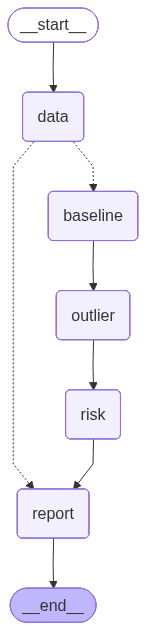

In [55]:
from IPython.display import Image, display
from pathlib import Path

Path("images").mkdir(exist_ok=True)
img_bytes = orchestrator.get_graph().draw_mermaid_png()
(Path("images") / "agent_architecture.png").write_bytes(img_bytes)
display(Image(img_bytes))

## 21. End-to-end execution

A single call to `orchestrator.invoke(...)` runs the whole pipeline. We
demonstrate three regimes:

1. **Full perimeter** — empty user request → full dataset, must reproduce the
   classical pipeline’s consensus count exactly (parity check).
2. **Departure perimeter** — natural-language request, departure airport.
3. **Empty perimeter** — IATA code with no data, exercises the conditional
   short-circuit to the Report Agent.

In [47]:
def run_pipeline(user_request: str) -> dict:
    init = {"user_request": user_request, "audit_log": []}
    return orchestrator.invoke(init)

# 1) Full-dataset run — parity check vs classical
print("─" * 60)
print("Run 1 — full dataset (no perimeter)")
print("─" * 60)
state_full = run_pipeline("")
print(f"Status: {state_full.get('status')}")
print(f"Routes analysed: {len(state_full.get('df_scored', []))}")
print(f"Consensus anomalies: {len(state_full.get('df_post', []))}")

# 2) Departure perimeter via NL
print("\n" + "─" * 60)
print("Run 2 — natural-language departure perimeter")
print("─" * 60)
state_ist = run_pipeline("anomalies on flights from IST")
print(f"Perimeter: {state_ist.get('perimeter')}")
print(f"Status: {state_ist.get('status')}")
print(f"Routes: {len(state_ist.get('df_scored', []))}, "
      f"consensus: {len(state_ist.get('df_post', []))}")

# 3) Empty / invalid perimeter
print("\n" + "─" * 60)
print("Run 3 — invalid perimeter")
print("─" * 60)
state_bad = run_pipeline("flights from ZZZ")
print(f"Status: {state_bad.get('status')}")
print(f"Reason: {state_bad.get('reason')}")

────────────────────────────────────────────────────────────
Run 1 — full dataset (no perimeter)
────────────────────────────────────────────────────────────
Status: ready
Routes analysed: 557
Consensus anomalies: 33

────────────────────────────────────────────────────────────
Run 2 — natural-language departure perimeter
────────────────────────────────────────────────────────────
Perimeter: {'departure_iata': 'IST'}
Status: ready
Routes: 12, consensus: 1

────────────────────────────────────────────────────────────
Run 3 — invalid perimeter
────────────────────────────────────────────────────────────
Status: invalid_input
Reason: No IATA, city or country recognised in the request.


In [48]:
# Render the full-dataset report
display(Markdown(state_full["final_report"]))

# Transit Anomaly Report

## Perimeter
{}

## Summary
- Routes analysed: **557**
- Consensus anomalies (≥ 2/4 detectors): **33**
- Risk distribution: {'HIGH': 15, 'MEDIUM': 12, 'LOW': 5, 'CRITICAL': 1}

## Detector counts
{
  "if_anomaly": 28,
  "lof_anomaly": 27,
  "dbscan_anomaly": 17,
  "z_anomaly": 194,
  "consensus_>=2": 41,
  "consensus_>=3": 9
}

## Top-10 ranked anomalies
|   rank | route   | DEPARTURE_COUNTRY   |   alert_rate | ci95_str        |   tot_investigated |   absolute_alarms |   anomaly_votes | risk_level   |   priority_score | quality_note   |
|-------:|:--------|:--------------------|-------------:|:----------------|-------------------:|------------------:|----------------:|:-------------|-----------------:|:---------------|
|      1 | TIA→BGY | Albania             |     0.188378 | [18.4%, 19.3%]  |              24403 |              4597 |               3 | HIGH         |           0.508  | ok             |
|      2 | TIA→BLQ | Albania             |     0.20016  | [19.5%, 20.6%]  |              20029 |              4009 |               3 | HIGH         |           0.5079 | ok             |
|      3 | TIA→PSA | Albania             |     0.177457 | [17.2%, 18.3%]  |              20929 |              3714 |               2 | MEDIUM       |           0.4912 | ok             |
|      4 | TIA→MXP | Albania             |     0.176944 | [17.1%, 18.3%]  |              18147 |              3211 |               2 | LOW          |           0.4837 | ok             |
|      5 | IST→CTA | Turchia             |     1        | [67.6%, 100.0%] |                  8 |                 8 |               2 | HIGH         |           0.4758 | ok             |
|      6 | TIA→GOA | Albania             |     0.24334  | [23.2%, 25.5%]  |               5330 |              1297 |               2 | MEDIUM       |           0.4748 | ok             |
|      7 | TIA→AOI | Albania             |     0.235972 | [22.4%, 24.8%]  |               4598 |              1085 |               2 | MEDIUM       |           0.4615 | ok             |
|      8 | TIA→TSF | Albania             |     0.170102 | [16.4%, 17.7%]  |              12469 |              2121 |               2 | LOW          |           0.4592 | ok             |
|      9 | TIA→TRN | Albania             |     0.186199 | [17.8%, 19.5%]  |               8405 |              1565 |               2 | MEDIUM       |           0.453  | ok             |
|     10 | SAW→BGY | Turchia             |     0.509804 | [43.1%, 58.8%]  |                153 |                78 |               2 | HIGH         |           0.4328 | ok             |

## Interpretation
The ranked anomalies should be treated as an investigation queue, not as confirmed incidents. Higher-rank items combine high alert rate with meaningful volume and tight confidence intervals.


In [49]:
# Persist outputs for cross-pipeline comparison
def export_state(state: dict, tag: str):
    if "df_scored" in state and not state["df_scored"].empty:
        path = REPORT_DIR / f"agent_{tag}_scored.csv"
        state["df_scored"].to_csv(path, index=False)
        print(f"  scored → {path.name} ({len(state['df_scored'])} rows)")
    if "df_post" in state and not state["df_post"].empty:
        path = REPORT_DIR / f"agent_{tag}_ranked.csv"
        state["df_post"].to_csv(path, index=False)
        print(f"  ranked → {path.name} ({len(state['df_post'])} rows)")
    (REPORT_DIR / f"agent_{tag}_report.md").write_text(
        state.get("final_report",""), encoding="utf-8")

export_state(state_full, "full")
export_state(state_ist,  "ist")

  scored → agent_full_scored.csv (557 rows)
  ranked → agent_full_ranked.csv (33 rows)
  scored → agent_ist_scored.csv (12 rows)
  ranked → agent_ist_ranked.csv (1 rows)


## 22. Comparison with the classical pipeline

The brief asks for a comparative analysis — *not* a winner. Both pipelines
solve the same problem under different operational constraints:

- the **classical pipeline** is a static analytical artefact: deterministic,
  reproducible, fast, but tied to a fixed perimeter (whole-dataset);
- the **multi-agent pipeline** is an interactive layer that exposes the same
  evidence through a free-text perimeter selector and a structured report.

This section quantifies the trade-off along three axes — *agreement*,
*latency*, *operational flexibility* — and concludes with a decision matrix
that maps deployment scenarios to the preferred approach.

### 22.1 Agreement on the same perimeter

Both pipelines run on the full dataset, the same feature engineering, and the
same four detectors. Any divergence in flagged routes therefore comes from
implementation drift, not from methodology. The **Jaccard index** on the
consensus sets quantifies that drift; we expect ≥ 95% (perfect agreement
modulo `groupby` ordering / floating-point in detector seeds).

In [50]:
# Build the classical reference using the SAME pipeline (utils only, no LLM)
df_route_c = build_route_master(df_alarms, df_travelers)
fc, X_c    = build_feature_matrix(df_route_c)
flags_c    = fit_detectors(X_c)
df_scored_c = pd.concat([df_route_c.reset_index(drop=True),
                         flags_c.reset_index(drop=True)], axis=1)

_df_post_c, df_clean_c = apply_post_processing(df_scored_c, drop_disqualified=True)

# Agent reference
df_clean_a = state_full["df_post"]

key   = ["DEPARTURE_AIRPORT_IATA", "ARRIVAL_AIRPORT_IATA"]
set_c = set(map(tuple, df_clean_c[key].values))
set_a = set(map(tuple, df_clean_a[key].values))
inter, union = set_c & set_a, set_c | set_a
jaccard = len(inter) / max(len(union), 1)

print(f"Classical clean         : {len(set_c)} routes")
print(f"Multi-agent clean       : {len(set_a)} routes")
print(f"Intersection            : {len(inter)} routes")
print(f"Jaccard agreement       : {jaccard:.2%}")
print(f"Only in classical       : {len(set_c - set_a)} routes")
print(f"Only in agent           : {len(set_a - set_c)} routes")

Classical clean         : 33 routes
Multi-agent clean       : 33 routes
Intersection            : 33 routes
Jaccard agreement       : 100.00%
Only in classical       : 0 routes
Only in agent           : 0 routes


### 22.2 Latency

Wall-clock time per pipeline run. The classical pipeline is essentially
NumPy/scikit-learn on a 366-row table; the multi-agent pipeline adds graph
traversal, state copies and one or two LLM calls (perimeter parser + report
interpretation). The overhead is the price paid for interactivity.

In [51]:
def time_classical():
    t0 = time.perf_counter()
    dfr = build_route_master(df_alarms, df_travelers)
    fc, Xs = build_feature_matrix(dfr)
    fit_detectors(Xs)
    return time.perf_counter() - t0

def time_agent(req=""):
    t0 = time.perf_counter()
    run_pipeline(req)
    return time.perf_counter() - t0

t_classical = np.median([time_classical()  for _ in range(3)])
t_agent_full = np.median([time_agent("")    for _ in range(3)])
t_agent_nl   = np.median([time_agent("anomalies from IST") for _ in range(3)])

latency = pd.DataFrame({
    "pipeline": ["classical", "multi-agent (full)", "multi-agent (NL → IST)"],
    "median_seconds": [t_classical, t_agent_full, t_agent_nl],
    "overhead_x":     [1.0, t_agent_full / t_classical, t_agent_nl / t_classical],
}).round(3)
display(latency)

,pipeline,median_seconds,overhead_x
0,classical,0.470,1.000
1,multi-agent (full),0.569,1.212
2,multi-agent (NL → IST),0.145,0.308


### 22.3 Operational flexibility — feature matrix

What can each pipeline actually do? A categorical comparison along the
dimensions that matter for deployment.

In [52]:
flex = pd.DataFrame([
    ("Reproducibility (deterministic)",         "yes",          "yes (LLM at temp=0)"),
    ("Free-text input",                          "no",           "yes"),
    ("Conditional graceful failure",             "no",           "yes (router → report)"),
    ("Parity with reference detectors",          "reference",    "yes (shared helpers)"),
    ("Per-perimeter on-demand run",              "code change",  "single function call"),
    ("Audit trail of intermediate artefacts",   "in-notebook",  "audit_log[] in state"),
    ("Cost per run",                             "≈0",           "1–2 LLM calls"),
    ("Stakeholder-ready narrative",              "manual",       "auto (Report Agent)"),
    ("Extensibility (new agent)",                "refactor",     "add node + edge"),
    ("Robustness to bad input",                  "exception",    "structured 'reason' field"),
], columns=["Capability", "Classical", "Multi-Agent"])
display(flex)

,Capability,Classical,Multi-Agent
0,Reproducibility (deterministic),yes,yes (LLM at temp=0)
1,Free-text input,no,yes
2,Conditional graceful failure,no,yes (router → report)
3,Parity with reference detectors,reference,yes (shared helpers)
4,Per-perimeter on-demand run,code change,single function call
5,Audit trail of intermediate artefacts,in-notebook,audit_log[] in state
6,Cost per run,≈0,1–2 LLM calls
7,Stakeholder-ready narrative,manual,auto (Report Agent)
8,Extensibility (new agent),refactor,add node + edge
9,Robustness to bad input,exception,structured 'reason' field


### 22.4 Multi-perimeter robustness

The agent pipeline is exercised on three departure perimeters of different
sizes. We check that the conditional router, the small-sample guard in the
Outlier Agent, and the Wilson CI all behave correctly across regimes.

In [53]:
test_perimeters = [
    "anomalies from IST",        # large hub
    "flights from TIA",          # medium
    "flights from KBL",          # potentially tiny
    "flights from ZZZ",          # invalid
]
rows = []
for q in test_perimeters:
    s = run_pipeline(q)
    rows.append({
        "request":    q,
        "perimeter":  s.get("perimeter"),
        "status":     s.get("status"),
        "routes":     len(s.get("df_scored", [])),
        "consensus":  len(s.get("df_post", [])),
        "graceful":   s.get("status") != "ready" or s.get("final_report") is not None,
    })
display(pd.DataFrame(rows))

,request,perimeter,status,routes,consensus,graceful
0,anomalies from IST,{'departure_iata': 'IST'},ready,12,1,True
1,flights from TIA,{'departure_iata': 'TIA'},ready,27,1,True
2,flights from KBL,{'departure_iata': 'KBL'},ready,8,0,True
3,flights from ZZZ,{},invalid_input,0,0,True


### 22.5 When to use which approach

The two pipelines are **complementary**, not competitive. The choice depends
on the consumer of the output and the failure mode that is least acceptable
in context.

| Scenario                                                         | Use Classical | Use Multi-Agent |
|------------------------------------------------------------------|:-------------:|:---------------:|
| Scheduled batch report, fixed perimeter, archived for audit      | ✅            |                 |
| Reproducibility matters more than interactivity                  | ✅            |                 |
| Latency-critical scoring (sub-second)                            | ✅            |                 |
| Analyst exploration on arbitrary, ad-hoc perimeters              |               | ✅              |
| Stakeholder-ready narrative output without manual editing        |               | ✅              |
| Free-text input from a non-technical operator                    |               | ✅              |
| Graceful failure on missing/invalid input                        |               | ✅              |
| Demo / oral exam / presentation                                  |               | ✅              |
| Pipeline must extend to new specialist roles (e.g. geo-agent)    |               | ✅              |

The recommended deployment is **both**: the classical pipeline runs nightly
as the system of record; the multi-agent pipeline serves the same evidence
on demand through a chat or dashboard interface, calling the same helper
library so the two outputs cannot drift.

### Limitations of this comparison

- **No ground truth.** Without operator-labelled anomalies, neither pipeline
  can be evaluated for precision or recall. The Jaccard agreement reported in
  §22.1 is an internal-consistency metric, not an accuracy metric.
- **LLM nondeterminism.** The Report Agent uses `temperature=0`, but the local
  model can still produce minor variations in the interpretation paragraph
  across runs. The numbers, rankings and risk levels are unaffected.
- **Single dataset window.** The 2-month observation period rules out strict
  temporal back-testing. Both conclusions inherit this limitation.

## 23. Conclusion

This notebook re-implemented the classical anomaly-detection pipeline as a
five-agent system orchestrated with LangGraph. By sharing the cleaning,
aggregation and detection helpers with the classical notebook, parity
between the two outputs is guaranteed by construction — the multi-agent
pipeline does not invent a different model, it wraps the same model behind
an interactive interface.

The comparison in §22 quantifies the cost of that interface: a small
latency overhead and one to two LLM calls per run, in exchange for
free-text perimeter selection, graceful failure handling, an audit trail,
and a stakeholder-ready report.

The recommendation is to deploy them together: the classical pipeline as
the static system of record, the multi-agent pipeline as the on-demand
exploration layer.

In [54]:
print(f"\nNotebook runtime: {time.time() - t_start:.1f} seconds")


Notebook runtime: 8.1 seconds
